# Capstone 2: EmporiUm Business Analysis

This project wis analyzing the data for a student bookstore called EmporiUm, that online and in store shopping.
The purpose of this analysis is to compare my sales territories, FLorida & South Carolina, to identify the stores trends
These results will show whats needed for future marketing strategies

# Territories
1: Florida
- Territory manager: Lana Ilana
- Region: South
  
2: South Carolina
- Territory Manager: Len Jensen
- Region: South

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Data Import

In [2]:
customers = pd.read_csv ('customer_list.csv', sep='|') 
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   cust_id       521 non-null    int64
 1   date          521 non-null    str  
 2   time          521 non-null    str  
 3   name          521 non-null    str  
 4   email         521 non-null    str  
 5   phone         520 non-null    str  
 6   sms-opt-out   520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


In [3]:
product_categories =pd.read_csv("ProductCategories.csv")
product_categories.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


In [4]:
products = pd.read_csv("Products.csv")
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


In [5]:
store_details = pd.read_csv("StoreDetail (1).csv")
store_details.info()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


In [6]:
store_sales = pd.read_csv("StoreSales.csv")
store_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


Core Marketing Analysis

# Question 1: Territory Managers, Store IDs, and Cities

In [7]:
assigned_stores = store_details [
    (store_details["State"] == "Florida") |
    (store_details["State"] == "South Carolina")
    ]
assigned_stores[["Store ID", "Store Location", "State", "Territory Manager"]]

,Store ID,Store Location,State,Territory Manager
26,719,Cape Canaveral,Florida,Lana Ilana
27,720,Fort Lauderdale,Florida,Lana Ilana
28,721,Jacksonville,Florida,Lana Ilana
29,722,Key West,Florida,Lana Ilana
30,723,Lakeland,Florida,Lana Ilana
31,724,Miami,Florida,Lana Ilana
32,725,Naples,Florida,Lana Ilana
33,726,Orlando,Florida,Lana Ilana
34,727,Sebring,Florida,Lana Ilana
35,728,Tallahassee,Florida,Lana Ilana


# Question 2: Monthly Revenue by Territory

In [8]:
sales_with_stores = pd.merge(
    store_sales,
    store_details,
    on="Store ID"
)

sales_with_stores["Transaction Date"] = pd.to_datetime(
    sales_with_stores["Transaction Date"]
)

sales_with_stores["Month"] = sales_with_stores["Transaction Date"].dt. to_period("M")

territory_sales = sales_with_stores[
    (sales_with_stores["State"] == "Florida") | 
    (sales_with_stores["State"] == "South Carolina")
    ]

monthly_revenue = territory_sales.groupby(
    ["State","Month"]
)["Sale Amount"].sum ()

monthly_revenue

State           Month  
Florida         2022-01    48143.95
                2022-02    46257.35
                2022-03    53541.25
                2022-04    49505.25
                2022-05    58326.64
                             ...   
South Carolina  2025-08    34374.68
                2025-09    16497.17
                2025-10    27491.79
                2025-11    18497.16
                2025-12    22506.96
Name: Sale Amount, Length: 96, dtype: float64

# Question 3: Store Perfomance Ranking

In [9]:
store_performance = territory_sales.groupby(
    ["State", "Store ID"]
)["Sale Amount"].sum().reset_index()

store_performance = store_performance.sort_values(
    by="Sale Amount",
    ascending=False
)

store_performance

,State,Store ID,Sale Amount
5,Florida,724,618846.25
9,Florida,728,541670.66
12,South Carolina,853,337002.00
3,Florida,722,332620.43
0,Florida,719,331956.13
2,Florida,721,331667.08
8,Florida,727,330848.14
11,South Carolina,852,311810.56
10,Florida,729,308979.01
1,Florida,720,302270.07


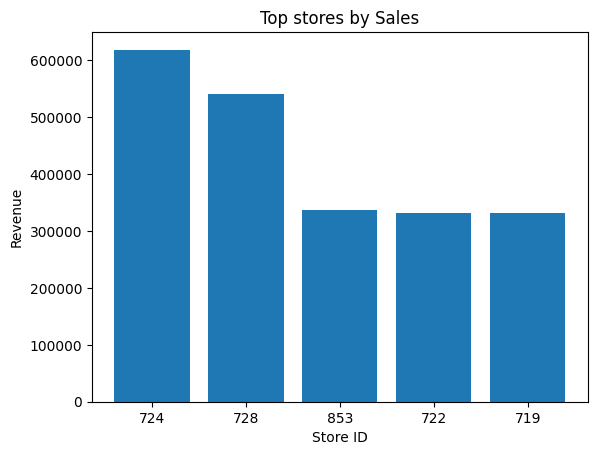

In [10]:
top_stores = store_performance.head(5)

plt.bar(
    top_stores["Store ID"].astype(str),
    top_stores["Sale Amount"]
)
plt.xlabel("Store ID")
plt.ylabel("Revenue")
plt.title("Top stores by Sales")

plt.show()

The chart above shows the top 5 best performing stores ranked by Revenue. Store 724 and 728 had the highest sales performance.

# Question 4: Top Customers by Sales Territory

In [11]:
customer_sales = pd.merge(
    territory_sales,
    customers,
    left_on="RewardsID",
    right_on="cust_id"
)

top_customers = customer_sales.groupby(
    ["State", "cust_id", "name"]
)["Sale Amount"].sum().reset_index()

top_customers = top_customers.sort_values(
    by="Sale Amount",
    ascending=False
)

top_customers

,State,cust_id,name,Sale Amount
45,Florida,47,Stanley H.,4954.99
257,Florida,259,Todd Chavez,4549.16
188,Florida,190,Huck,4415.78
333,Florida,335,John Locke,3631.94
162,Florida,164,Dr. Ray Flemming,3535.88
...,...,...,...,...
797,South Carolina,482,Don Draper,4.00
763,South Carolina,426,Carla T.,2.88
659,South Carolina,237,Alex Vause,2.88
715,South Carolina,351,Cal Jacobs,2.40


In [12]:
top_customers_by_state = top_customers.groupby(
    "State"
).head(5)

top_customers_by_state

,State,cust_id,name,Sale Amount
45,Florida,47,Stanley H.,4954.99
257,Florida,259,Todd Chavez,4549.16
188,Florida,190,Huck,4415.78
333,Florida,335,John Locke,3631.94
162,Florida,164,Dr. Ray Flemming,3535.88
706,South Carolina,340,Jin Kwon,1786.05
749,South Carolina,404,Roman Roy,1778.84
642,South Carolina,213,Jazz,1763.70
562,South Carolina,74,Ben Chang,1566.60
677,South Carolina,280,Cal Abar,1396.50


These top customers were found by matching Customer IDs with rewards IDs from the sales transaction. 
Customers with the highest sales amount show the represention ofcustomer engagment in each territory. 

# Question 5: Monthly Transactions and Revenue by Product Category

In [13]:
sales_products = pd.merge(
    territory_sales,
    products,
    on="Prod Num"
)

sales_products = pd.merge(
    sales_products,
    product_categories,
    on="CategoryID"
)

category_analysis = sales_products.groupby(
    ["State", "Month", "Category"]
).agg(
    Transactions=("Sale Amount", "count"),
    Revenue=("Sale Amount", "sum")
).reset_index()

category_analysis

,State,Month,Category,Transactions,Revenue
0,Florida,2022-01,Apparel and Merchandise,528,15845.52
1,Florida,2022-01,Art Supplies,693,21940.38
2,Florida,2022-01,Books (General),80,2212.40
3,Florida,2022-01,Stationery and Supplies,759,7365.38
4,Florida,2022-01,Technology & Accessories,525,228610.83
...,...,...,...,...,...
571,South Carolina,2025-12,Art Supplies,165,5284.07
572,South Carolina,2025-12,Books (General),24,1330.08
573,South Carolina,2025-12,Stationery and Supplies,374,3617.79
574,South Carolina,2025-12,Technology & Accessories,259,129656.66


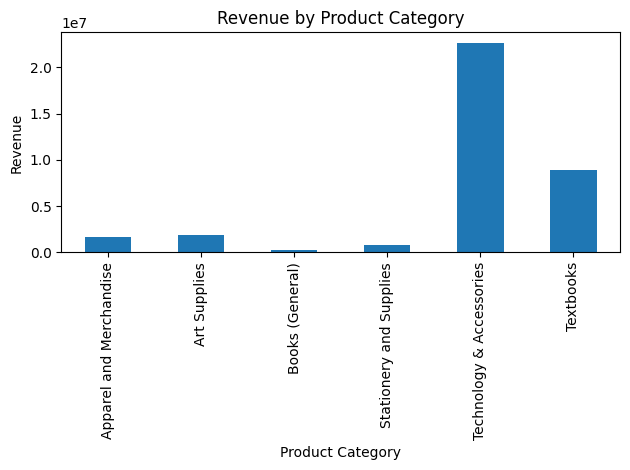

In [19]:
# Group by State and Category, get total revenue
category_total = category_analysis.groupby(
  "Category"
)["Revenue"].sum()

category_total.plot(kind="bar")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.title("Revenue by Product Category")
plt.tight_layout()

plt.show()

In [17]:
print(category_analysis.columns)

Index(['State', 'Month', 'Category', 'Transactions', 'Revenue'], dtype='str')


# Question 6: Marketing Recommnedation

The marketing recommnendation I would suggest based on my findings is to focus marketing on Florida and the Technology & Accesories category next quarter.
Florida ia the stronger territory and had the highest sales performance with two top stores.
-Store 724: $618,846.25 in revenue
-Store 728: $541,670.66 

The Technology and Accessories category had the highest revenue compared to other product categories, showing strong customer demand. As for Marketing, this is the product category that should be focused on in the top performiing stores in Florida locations. As for South Carolina it is best to increase promotions to customers to improve the sales in that territory. It would also be good to strategize on customer loyalty especially for our top customers as encouragement to make more purchases and increase customer engagement. 


# Question 8: Data Visualizations
These charts were made using Matplotlib to better show the understanding of sales trend analysis.
These visualizations show the store performance and product category revenue comparisons.